# ESG Screening and RAG: Implemented Classifier vs Interface Contract

**Docker image**: `ml4t-gpu`

**Book Reference**: Chapter 22, Section 22.8 (Applications and Strategic Choices)

Two ways to do ESG analysis, and only one of them is implemented here.

1. **Keyword screening plus a pretrained sentiment model.** Built and run:
   headlines are selected by an ESG keyword list, labelled E, S or G by a
   second keyword list, and scored by FinBERT. It produces a row per headline
   that a factor model can consume.
2. **A RAG assistant.** Not built here. What is recorded instead is the
   contract such an assistant would have to satisfy - narrative answers,
   cited spans, abstention - so that the comparison stays a comparison of
   output types rather than an invented benchmark.

The screening path turns out to demonstrate its own principal limitation
without being asked to. Section 2 measures it: over the Bloomberg archive,
the keyword screen that selects "ESG-relevant" headlines selects almost
nothing but environmental ones, and the reason is a property of the language
rather than of the list.

**Learning objectives**

After working through this notebook you will be able to:

- Say what a fixed taxonomy costs, from a measurement rather than an
  assertion.
- Recognise why a keyword screen finds environmental topics far more readily
  than social or governance ones.
- Separate a model's inference cost from the one-off cost of loading it.
- State the evidence contract a RAG producer has to meet before its output
  can be compared with a classifier's.

**Prerequisites**: the Bloomberg financial news archive
(`data/alternative/news/bloomberg/`). No RAG answers are generated here.

## 1. Setup

In [1]:
"""ESG Analysis: RAG vs Fine-Tuning - Comparing classification and retrieval approaches."""

import hashlib
import json
import time

import plotly.graph_objects as go

# Core imports
import polars as pl
import torch
from plotly.subplots import make_subplots
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline
from transformers.utils import logging as transformers_logging

# ML4T configuration
from data import load_bloomberg_news
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, show_plotly_with_alt

transformers_logging.set_verbosity_error()

In [2]:
MAX_HEADLINES = 0  # 0 means PER_CATEGORY from each of E, S and G
MAX_QUESTIONS = 0
PER_CATEGORY = 7  # headlines drawn from each ESG category, subject to supply
SEED = 42
REQUIRE_GPU = True
FINBERT_MODEL = "ProsusAI/finbert"
FINBERT_REVISION = "4556d13015211d73dccd3fdd39d39232506f3e43"

In [3]:
set_global_seeds(SEED)
if REQUIRE_GPU and not torch.cuda.is_available():
    raise RuntimeError("FinBERT inference requires the ml4t-gpu service with CUDA.")
INFERENCE_DEVICE = 0 if torch.cuda.is_available() else -1
print(f"FinBERT device: {'cuda:0' if INFERENCE_DEVICE == 0 else 'cpu'}")

FinBERT device: cuda:0


## 2. What the keyword screen actually selects

The screen is two keyword lists. The first decides which headlines are
ESG-relevant at all; the second sorts those into Environmental, Social and
Governance. Both are below, and the second is applied to the whole selected
pool before any sampling, because what the pool contains decides what a
sample can show.

In [4]:
news_df = load_bloomberg_news()
required_columns = {"timestamp", "headline"}
missing_columns = required_columns - set(news_df.columns)
if missing_columns:
    raise ValueError(f"Bloomberg news loader violates canonical schema: missing {missing_columns}.")

ESG_SELECTION_PATTERN = (
    r"(?i)(climate|carbon|emission|sustain|ESG|renewable|diversity|governance|environmental"
    r"|green.bond|pollution|social.responsibility|net.zero|solar|wind.energy|deforestation"
    r"|water.scarcity|labor.rights|board.independence|executive.compensation)"
)
esg_news = (
    news_df.filter(pl.col("headline").str.contains(ESG_SELECTION_PATTERN))
    .filter(pl.col("headline").str.len_chars() > 30)
    .sort(["timestamp", "headline"], descending=[True, False])
)
print(
    f"Archive spans {news_df['timestamp'].min():%Y-%m-%d} to {news_df['timestamp'].max():%Y-%m-%d}"
)
print(f"Headlines in archive: {news_df.height:,}")
print(f"Headlines the ESG screen selects: {esg_news.height:,}")

Archive spans 2006-10-20 to 2013-11-26
Headlines in archive: 446,762
Headlines the ESG screen selects: 7,293


### The E, S and G taxonomy

A second keyword list sorts a selected headline into one category. The terms
are the ones an analyst would reach for first, and the order matters:
environmental is tested before social and social before governance, so a
headline about a board's climate policy counts as environmental.

In [5]:
ESG_CATEGORY_TERMS = {
    "Environmental": [
        "carbon",
        "emission",
        "environmental",
        "environment",
        "solar",
        "sustainab",
        "net-zero",
        "net zero",
        "climate",
        "renewable",
        "wind",
        "pollution",
        "deforestation",
        "water scarcity",
        "green bond",
        "clean energy",
    ],
    "Social": [
        "worker",
        "safety",
        "labor",
        "labour",
        "diversity",
        "data breach",
        "customer",
        "human rights",
        "community",
        "social responsibility",
    ],
    "Governance": [
        "board",
        "ceo",
        "chief executive",
        "compensation",
        "shareholder",
        "governance",
        "audit",
        "disclosure",
    ],
}


def categorize_esg(text: str) -> str:
    """Assign one ESG category by keyword, or Other when no term matches."""
    lowered = text.lower()
    for category, terms in ESG_CATEGORY_TERMS.items():
        if any(term in lowered for term in terms):
            return category
    return "Other"

### What the pool contains

Apply the taxonomy to every selected headline before sampling any of them.

In [6]:
esg_news = esg_news.with_columns(
    pl.col("headline").map_elements(categorize_esg, return_dtype=pl.String).alias("category")
)
pool_counts = esg_news.group_by("category").len().sort("len", descending=True)
pool_counts

category,len
str,u32
"""Environmental""",6988
"""Other""",168
"""Governance""",86
"""Social""",51


The screen is called an ESG screen and it is an environmental screen. The
counts above are not close: the environmental category takes the
overwhelming majority of what the first keyword list selects, and social and
governance headlines together are a rounding error against it.

The cause is in the vocabulary rather than in the list. Environmental
reporting has words of its own - *solar*, *carbon*, *emissions*,
*renewables* - that appear almost nowhere else, so a keyword screen catches
it cleanly. Social and governance topics are written in ordinary business
English: *board*, *pay*, *workers*, *safety*. A list broad enough to catch
those would select most of a financial news archive, and a list narrow
enough to be precise catches almost none of them. No amount of care with the
keywords escapes that, which is what "fixed taxonomy" costs in practice.

It also decides how to sample. Drawing twenty headlines uniformly from this
pool would, on these proportions, produce twenty environmental headlines and
demonstrate a one-letter taxonomy. The sample below is stratified instead,
taking the same number from each category so that all three are present -
which is itself the admission that the screen could not supply them by
itself.

In [7]:
per_category = MAX_HEADLINES if MAX_HEADLINES > 0 else PER_CATEGORY
selected_headlines = pl.concat(
    [
        group.sample(min(per_category, group.height), seed=SEED)
        for category in ("Environmental", "Social", "Governance")
        if (group := esg_news.filter(pl.col("category") == category)).height
    ]
).sort(["timestamp", "headline"], descending=[True, False])
ESG_HEADLINES = selected_headlines["headline"].to_list()
selection_sha256 = hashlib.sha256(
    "\n".join(
        f"{row['timestamp'].isoformat()}|{row['headline']}"
        for row in selected_headlines.iter_rows(named=True)
    ).encode()
).hexdigest()
print(f"Stratified sample: {len(ESG_HEADLINES)} headlines")
print(dict(selected_headlines.group_by("category").len().sort("category").iter_rows()))
print(f"Selected-row SHA-256: {selection_sha256}")

Stratified sample: 21 headlines
{'Environmental': 7, 'Governance': 7, 'Social': 7}
Selected-row SHA-256: 4c16924280aae65eb858e2824f92b9e4b3a9a7dcd43fc051be841f429d0394eb


### Sentiment-based headline classification

Uses FinBERT as a sentiment proxy. In production, a dedicated ESG
classifier (e.g., FinBERT-ESG) would replace this with a fine-grained
taxonomy output.

### Load the sentiment classifier

Production requires the pinned FinBERT snapshot. A missing dependency fails
closed instead of silently changing the model behind the reported results.


In [8]:
def load_finbert_pipeline():
    """Return the pinned FinBERT sentiment pipeline."""
    tokenizer = AutoTokenizer.from_pretrained(
        FINBERT_MODEL,
        revision=FINBERT_REVISION,
        local_files_only=True,
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        FINBERT_MODEL,
        revision=FINBERT_REVISION,
        local_files_only=True,
    )
    classifier = pipeline(
        "sentiment-analysis",
        model=model,
        tokenizer=tokenizer,
        device=INFERENCE_DEVICE,
    )
    return classifier, FINBERT_MODEL

### Classify the sample

Apply FinBERT, attach the E/S/G label, and time the load separately from the
inference. A throughput figure that includes the one-off cost of loading the
weights is a statement about the batch size it happened to be measured at,
not about the model - at twenty headlines the load dominates, and a reader
sizing a nightly job off it would be out by an order of magnitude.

In [9]:
def classify_esg_headlines(headlines: list) -> pl.DataFrame:
    """Classify headlines with FinBERT, timing the load and the inference apart."""
    load_start = time.time()
    classifier, model_used = load_finbert_pipeline()
    load_seconds = time.time() - load_start

    parameter_device = next(classifier.model.parameters()).device
    if REQUIRE_GPU and parameter_device.type != "cuda":
        raise RuntimeError(f"FinBERT parameters are on {parameter_device}, not CUDA.")
    print(f"Sentiment model in use: {model_used} on {parameter_device}")

    inference_start = time.time()
    results = []
    for headline in headlines:
        result = classifier(headline[:512])[0]  # truncate to the model's maximum
        results.append(
            {
                "headline": headline,
                "model": model_used,
                "category": categorize_esg(headline),
                "sentiment": result["label"],
                "confidence": result["score"],
            }
        )
    inference_seconds = time.time() - inference_start

    per_headline_ms = 1_000 * inference_seconds / max(len(headlines), 1)
    print(f"Model load:  {load_seconds:.2f}s, paid once per process")
    print(f"Inference:   {inference_seconds:.2f}s for {len(headlines)} headlines")
    print(
        f"             {per_headline_ms:.1f} ms each, {len(headlines) / inference_seconds:.0f} per second"
    )
    print(
        f"Load is {load_seconds / (load_seconds + inference_seconds):.0%} of the wall clock at "
        f"this batch size, and a smaller share of it at every larger one."
    )

    return pl.DataFrame(results).with_columns(
        pl.lit(per_headline_ms).alias("inference_ms_per_headline"),
        pl.lit(load_seconds).alias("model_load_seconds"),
    )

One row per headline, with a category, a label and a confidence. That shape
is what a factor pipeline can consume, and it is the structural advantage
classification holds over a narrative answer however good the narrative is.

In [10]:
# Run classification
print("=== Approach A: Pretrained FinBERT Inference ===\n")

classification_results = classify_esg_headlines(ESG_HEADLINES)
print("\nClassification Results:")
classification_results

=== Approach A: Pretrained FinBERT Inference ===



Sentiment model in use: ProsusAI/finbert on cuda:0


Model load:  0.69s, paid once per process
Inference:   0.23s for 21 headlines
             11.0 ms each, 91 per second
Load is 75% of the wall clock at this batch size, and a smaller share of it at every larger one.

Classification Results:


headline,model,category,sentiment,confidence,inference_ms_per_headline,model_load_seconds
str,str,str,str,f64,f64,f64
"""U.S. Tailors Regional Climate …","""ProsusAI/finbert""","""Environmental""","""neutral""",0.641695,11.008365,0.688295
"""Obama Diversity Promise Makes …","""ProsusAI/finbert""","""Social""","""neutral""",0.829148,11.008365,0.688295
"""Switzerland: Land of Corporate…","""ProsusAI/finbert""","""Governance""","""neutral""",0.920492,11.008365,0.688295
"""Facebook Seeking Head of Diver…","""ProsusAI/finbert""","""Social""","""neutral""",0.492827,11.008365,0.688295
"""EU Carbon Declines as Natural …","""ProsusAI/finbert""","""Environmental""","""negative""",0.874865,11.008365,0.688295
…,…,…,…,…,…,…
"""Fed’s Bullard Says Diversity o…","""ProsusAI/finbert""","""Social""","""positive""",0.782219,11.008365,0.688295
"""Isovoltaic Gets Solar IPO Pros…","""ProsusAI/finbert""","""Environmental""","""positive""",0.798064,11.008365,0.688295
"""China Longyuan Profit Doubled …","""ProsusAI/finbert""","""Environmental""","""positive""",0.936807,11.008365,0.688295


The `confidence` column is FinBERT's softmax over three sentiment classes. It
is not a probability that the label is right, and it says nothing at all
about the ESG category beside it, which came from a keyword match with no
uncertainty attached.

## Approach B: RAG Interface Contract

A RAG implementation must answer open-ended questions with retrieved evidence,
citations, and explicit abstention. This notebook records that contract without
inventing answers, citations, confidence, or latency.

In [11]:
# Sample ESG questions for RAG
ESG_QUESTIONS = [
    "Summarize the company's strategy for reducing Scope 2 emissions and list any stated targets.",
    "What key performance indicators does the company use to track progress on sustainability?",
    "Identify governance concerns related to executive compensation or board independence.",
]

if MAX_QUESTIONS > 0:
    ESG_QUESTIONS = ESG_QUESTIONS[:MAX_QUESTIONS]

### Declare the evidence contract

Each question defines the evidence a live assistant must return before its
output can enter a comparison.

In [12]:
def build_rag_contract(questions: list[str]) -> pl.DataFrame:
    """Return validation fields required from a future live RAG run."""
    return pl.DataFrame(
        {
            "question": questions,
            "required_output": ["grounded narrative"] * len(questions),
            "required_evidence": ["source id + quoted span"] * len(questions),
            "required_checks": ["citation support + abstention"] * len(questions),
            "measured_here": [False] * len(questions),
        }
    )

This is a specification and not a result. `05_10k_rag_assistant` implements
the retrieval half; a live generation run would still have to be scored for
citation support and abstention before either could be set against the
classifier above.

In [13]:
# Run RAG analysis
print("\n=== Approach B: RAG Interface Contract ===\n")

rag_contract = build_rag_contract(ESG_QUESTIONS)
print("\nRequired RAG evidence:")
rag_contract


=== Approach B: RAG Interface Contract ===


Required RAG evidence:


question,required_output,required_evidence,required_checks,measured_here
str,str,str,str,bool
"""Summarize the company's strate…","""grounded narrative""","""source id + quoted span""","""citation support + abstention""",false
"""What key performance indicator…","""grounded narrative""","""source id + quoted span""","""citation support + abstention""",false
"""Identify governance concerns r…","""grounded narrative""","""source id + quoted span""","""citation support + abstention""",false


`measured_here` is false in every row, and that column exists so the table
cannot be read as a result.

## Comparison: Classification vs RAG

This table separates the implemented screen from requirements that a future
RAG producer must satisfy.

In [14]:
# Build comparison table
comparison = pl.DataFrame(
    {
        "Dimension": [
            "Primary Output",
            "Scalability",
            "Flexibility",
            "Verifiability",
            "Knowledge Updates",
            "Latency",
            "Best Use Case",
        ],
        "Implemented Screening": [
            "Keyword category + sentiment label",
            "High (batch processing)",
            "Low (fixed taxonomy)",
            "Indirect (confidence)",
            "Update rules or replace model",
            "Measured here, load and inference apart",
            "Systematic factor construction",
        ],
        "RAG Contract": [
            "Requires narrative + citations",
            "Not measured here",
            "Open-ended by design",
            "Requires cited source spans",
            "Requires corpus provenance",
            "Not measured here",
            "Due-diligence interface specification",
        ],
    }
)

print("\n=== Approach Comparison ===\n")
comparison


=== Approach Comparison ===



Dimension,Implemented Screening,RAG Contract
str,str,str
"""Primary Output""","""Keyword category + sentiment l…","""Requires narrative + citations"""
"""Scalability""","""High (batch processing)""","""Not measured here"""
"""Flexibility""","""Low (fixed taxonomy)""","""Open-ended by design"""
"""Verifiability""","""Indirect (confidence)""","""Requires cited source spans"""
"""Knowledge Updates""","""Update rules or replace model""","""Requires corpus provenance"""
"""Latency""","""Measured here, load and infere…","""Not measured here"""
"""Best Use Case""","""Systematic factor construction""","""Due-diligence interface specif…"


The Flexibility row is the one this run puts a number behind. A fixed
taxonomy is low-flexibility in the sense measured in section 2: the screen
could not supply social or governance headlines in proportion, and no
reordering of the keyword list would have made it.

## Decision Framework

Use this framework to select the appropriate approach:

| Question | Choose Classification | Choose RAG |
|----------|----------------------|------------|
| Need to process 1000s of documents? | **Yes** | No |
| Need numeric time series? | **Yes** | No |
| Need to explain the reasoning? | No | **Yes** |
| Need to ask follow-up questions? | No | **Yes** |
| Need real-time processing? | **Yes** | Maybe |
| Knowledge changes frequently? | No | **Yes** |

In [15]:
# Performance comparison
print("\n=== Performance Statistics ===\n")

# Classification stats
if classification_results.height > 0:
    print("Classification Approach:")
    print(f"  Headlines processed: {classification_results.height}")
    print(f"  Unique categories: {classification_results['category'].n_unique()}")
    avg_confidence = classification_results["confidence"].mean()
    if avg_confidence is not None:
        print(f"  Average confidence: {avg_confidence:.2%}")

# RAG contract status
print("\nRAG Contract:")
print(f"  Questions specified: {rag_contract.height}")
print("  Answers generated: 0")
print("  Latency measured: No")


=== Performance Statistics ===

Classification Approach:
  Headlines processed: 21
  Unique categories: 3
  Average confidence: 79.90%

RAG Contract:
  Questions specified: 3
  Answers generated: 0
  Latency measured: No


Two of the three ESG categories are present in the sample only because the
sample was stratified to include them.

## 4. The screen, in two pictures

The sample's own category counts are equal by construction, so charting them
would draw the stratification rather than anything about the data. The left
panel shows the pool those categories were drawn from, on a log axis because
the counts span three orders of magnitude. The right panel is FinBERT's
sentiment over the stratified sample.

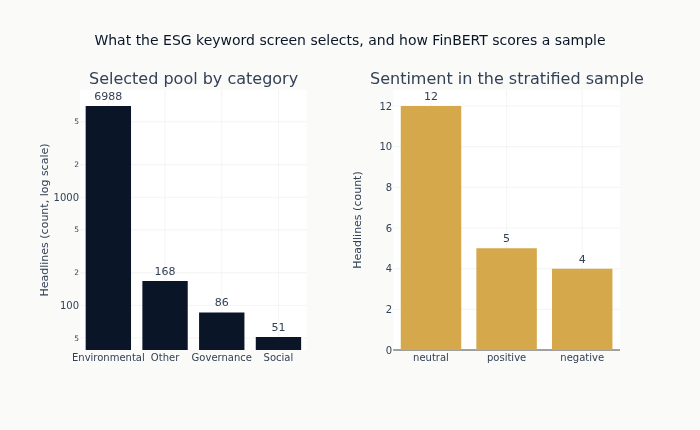

In [16]:
category_counts = classification_results.group_by("category").len().sort("len", descending=True)
sentiment_counts = classification_results.group_by("sentiment").len().sort("len", descending=True)

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Selected pool by category", "Sentiment in the stratified sample"),
    horizontal_spacing=0.16,
)
fig.add_trace(
    go.Bar(
        x=pool_counts["category"],
        y=pool_counts["len"],
        marker_color=COLORS["blue"],
        text=pool_counts["len"],
        textposition="outside",
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Bar(
        x=sentiment_counts["sentiment"],
        y=sentiment_counts["len"],
        marker_color=COLORS["amber"],
        text=sentiment_counts["len"],
        textposition="outside",
    ),
    row=1,
    col=2,
)
fig.update_layout(
    title="What the ESG keyword screen selects, and how FinBERT scores a sample",
    height=430,
    showlegend=False,
    margin=dict(t=90),
)
fig.update_yaxes(title_text="Headlines (count, log scale)", type="log", row=1, col=1)
fig.update_yaxes(title_text="Headlines (count)", row=1, col=2)
show_plotly_with_alt(
    fig,
    "Two bar panels. Left, the selected pool by ESG category on a logarithmic count axis: "
    "the environmental bar runs off the top of the others by more than an order of "
    "magnitude, with uncategorised, governance and social following far below it in that "
    "order. Right, sentiment over the stratified sample on a linear axis: neutral is the "
    "tallest bar, positive next, negative slightly below it.",
)

In [17]:
print("\n=== ESG Analysis Comparison Summary ===")
print(f"Classification: {classification_results.height} headlines -> numeric scores")
print(f"RAG: {rag_contract.height} question contracts -> no generated answers")
print("\nBoundary: execute and evaluate a cited RAG producer before comparing performance")


=== ESG Analysis Comparison Summary ===
Classification: 21 headlines -> numeric scores
RAG: 3 question contracts -> no generated answers

Boundary: execute and evaluate a cited RAG producer before comparing performance


In [18]:
completion_record = {
    "selected_rows_sha256": selection_sha256,
    "headlines": classification_results.height,
    "rag_questions": rag_contract.height,
    "models": classification_results["model"].unique().sort().to_list(),
    "model_revision": FINBERT_REVISION,
    "device": "cuda" if INFERENCE_DEVICE == 0 else "cpu",
    "category_counts": category_counts.to_dicts(),
    "sentiment_counts": sentiment_counts.to_dicts(),
}
print(f"COMPLETION_RECORD={json.dumps(completion_record, sort_keys=True)}")

COMPLETION_RECORD={"category_counts": [{"category": "Environmental", "len": 7}, {"category": "Social", "len": 7}, {"category": "Governance", "len": 7}], "device": "cuda", "headlines": 21, "model_revision": "4556d13015211d73dccd3fdd39d39232506f3e43", "models": ["ProsusAI/finbert"], "rag_questions": 3, "selected_rows_sha256": "4c16924280aae65eb858e2824f92b9e4b3a9a7dcd43fc051be841f429d0394eb", "sentiment_counts": [{"len": 12, "sentiment": "neutral"}, {"len": 5, "sentiment": "positive"}, {"len": 4, "sentiment": "negative"}]}


## Key takeaways

1. **An ESG keyword screen is an environmental screen.** Section 2 measures
   it over the whole selected pool, and the imbalance is not marginal. The
   reason is linguistic and not fixable by a longer list: environmental
   reporting has a vocabulary of its own, and social and governance topics
   are written in words that a precise list cannot catch and a broad one
   cannot separate from everything else. Any keyword taxonomy over news
   inherits this, and reporting an "ESG signal" built on one without checking
   its composition reports an environmental signal.

2. **A sample cannot show what its pool does not contain.** Twenty headlines
   drawn uniformly from this pool would be twenty environmental headlines.
   The stratified draw is what puts all three categories in front of the
   classifier, and stratifying is an intervention that has to be declared,
   because the resulting category counts are a property of the sampling
   rather than of the news.

3. **Time the load separately from the inference.** At this batch size the
   one-off cost of loading the weights is a large share of the wall clock, so
   a throughput figure computed over both describes the batch size rather
   than the model.

4. **Classification produces portfolio-ready outputs**, which is the reason
   to keep it: a row per document with a label and a score feeds a factor
   model directly, and a narrative answer does not, however well cited.

5. **The RAG side of this notebook is a contract, not a result.** No answers
   were generated, so no latency, no quality and no comparison is reported
   for it. `05_10k_rag_assistant` implements the retrieval half;
   `04_ragas_evaluation` is where the citation and abstention checks live.

**Next**: [`07_institutional_holdings_graph`](07_institutional_holdings_graph.ipynb)
builds graph-structured features from 13F filings.

**Book reference**: Section 22.8, on choosing between RAG and fine-tuning.